<a href="https://colab.research.google.com/github/dom-dang/7.C01/blob/main/7_C01_PSET_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  <center> Problem Set 4 (JAK2 - bio) <center>
<center> Spring 2025 <center>
<center> 3.C01/3.C51, 7.C01/7.C51, 10.C01/10.C51 20.C01/20.C51 <center>
<center> Due: Monday, April 27, 2026 at 3:00 PM ET <center>

<b>Name:</b> Dominique Dang

<b>Kerberos ID:</b> ddang

## Learning objective

In this problem set, you will first explore how to represent molecules using SMILES strings and Morgan fingerprints, then analyze these high-dimensional molecular representations using dimensionality-reduction techniques (PCA, t-SNE, and UMAP).  You will then take a real drug-discovery dataset, train multiple machine learning classifiers (SVM, RF, and DNN), and use SHAP to explain *why* each model makes its predictions — mapping the most important fingerprint bits back onto molecular structures and empirically validating the SHAP rankings through a feature-dropout experiment.

We will focus on the bioactivies of molecules targeting the receptors: JACK2 and Melatonin receptor 1B.

## Instructions

- This problem set has two parts with several sub-questions each. Some sub-questions are marked **grad version**, required for graduate students (X.C51) but optional for undergraduates.  Points for all students are in <font color="blue">blue</font>, while grad-only points are in <font color="orange">orange</font>.  The total points are **75 for undergraduates** and **100 for graduates**.

- To get started, make your own copy of this notebook template in Colab (e.g., “Save a copy in Drive”) before editing.

    - Part 1 does not require a GPU.  Part 2 (DNN training) benefits from one but can run on CPU.  The default Colab CPU runtime is sufficient for the full problem set.

- Collaboration is encouraged and AI tools are permitted, but submitting work that is not your own is plagiarism.  Any collaboration or assistance from others or from an LLM (including utilities integrated in Colab) must be described at the end of your submission.

- Additional notes about how to use this template:
    - Put your code in the code blocks flagged with `########## Code ##########`.

    - Numerical answers yielded from running the code should be included in an Answer Block (see next cell).

    - We have provided print statements where numerical answers are expected.

    - Your answer should be contained in a variable which you defined either in the Answer Block or the Code Block.

    - When a qualitative answer is expected, place those answers as text in the provided **Write answer here** cells.

- Submission: upload your completed notebook to Gradescope.  Ensure the notebook runs without error and includes all necessary code, plots, and outputs.

## Background

### SMILES for representing molecules

Whether it's designing specific ligands for enzyme inhibition, predicting the biological activity of small molecules, or exploring chemical space for drug discovery, understanding how to encode chemical structures is essential for computational biology (as well as computational chemistry, of course). The simplified molecular-input line-entry system (SMILES) is a text-based notation describing the structure of molecules using short ASCII strings. In terms of a graph-based computational procedure, SMILES strings are generated by printing the symbol nodes encountered in a [breadth-first traversal](https://en.wikipedia.org/wiki/Breadth-first_search) of the graphs, typically excluding hydrogen atoms. Any cycles are broken so that the graph becomes an acyclic (tree-structured) graph. Numbers indicate connections between non-adjacent characters in the SMILES string; parentheses are used to indicate points of branching on the tree.

Every molecule can be represented by multiple SMILES strings. For example, CCO, OCC, C(O)C, and [CH3][CH2][OH] all specify the structure of an ethanol molecule. There exist algorithms that can reproducibly generate a canonical SMILES string for a molecule. However, an arbitrary string of characters found in SMILES does not necessarily generate a SMILES string or a molecule; there is a fairly complex grammar that must be carefully respected.

<div align="center">
  <img src="https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps4-bio/figures/smiles.png" width="600px" />
</div>
<div align="center">A molecular structure can be represented by SMILES string (<a href="https://medium.com/starschema-blog/answering-the-big-questions-this-time-in-chemistry-ed5611669094">source</a>)</div>

### Molecular Fingerprints

In order to convert text-based SMILES strings into a mathematical format suitable for numerical algorithms, the cheminformatics community has developed a variety of algorithms. [Morgan et al.](https://doi.org/10.1021/ci100050t), also known as circular fingerprints, represent the molecular graph as a unique bit string that encodes the molecular topology.

Morgan fingerprints systematically capture the **local** chemical environments around each atom. You can think of this as a highly compressed summary of all the substructures present in a molecule.

How it works:

1. **Start at each atom (radius = 0):** Each atom is assigned an initial identifier based on properties like its element type, charge, and connectivity.
2. **Expand outward (increasing radius):** For radius = 1, 2, etc., the algorithm iteratively “grows” neighborhoods around each atom, much like concentric circles on a graph. At each step, it combines the atom’s current identifier with those of its neighbors to form a new identifier representing a larger substructure.
3. **Hash substructures:** Each unique substructure identifier is passed through a mathematical hash function, mapping it to one or more positions in a fixed-length vector (e.g., 512, 1024, or 2048 bits).
4. **Set bits:** If a substructure is present in the molecule, the corresponding bit in the vector is set to 1. The final fingerprint is the collection of all these 1s and 0s across all atoms and radii.

<div align="center">
  <img src="https://docs.chemaxon.com/latest/images/download/attachments/1806333/ecfp_generation.png" width="600px" />
</div>
<div align="center">Steps 1-3 of the Morgan fingerprint generation process (<a href="https://docs.chemaxon.com/latest/fingerprints_extended-connectivity-fingerprint-ecfp.html">source</a>)</div>


<div align="center">
  <img src="https://docs.chemaxon.com/latest/images/download/attachments/1806333/ecfp_folding.png" width="600px" />
</div>
<div align="center">Step 4 of the process (<a href="https://docs.chemaxon.com/latest/fingerprints_extended-connectivity-fingerprint-ecfp.html">source</a>)</div>


**Properties and Limitations**
The “radius” controls how much of the molecular context you capture: a small radius captures very local features, while a larger radius captures more global structure. Because the hash function maps many possible substructures into a limited number of bits, "bit collisions" can occur, meaning different substructures might accidentally activate the same bit. Using higher dimensional vectors (like 1024 or 2048) maximizes descriptive power and reduces the risk of these collisions.

#### ECFP4 (What you’ll use)

**Extended-Connectivity Fingerprints (ECFP)** are a specific, widely used implementation of Morgan fingerprints. In this assignment, we will use **ECFP4**, which simply means a Morgan fingerprint with a radius of 2 (the "4" refers to the diameter.  ECFP4 strikes an excellent balance between capturing meaningful chemical context and keeping the representation compact. We provide the code to convert your SMILES strings into N-dimensional ECFP4 fingerprints using the implementation found in the open-source [RDKit](https://www.rdkit.org) package.

By using fingerprints, machine learning models can learn to correlate molecular substructures to the property being predicted.

## Imports

In [1]:
!uv pip install molvs rdkit mols2grid

Using Python 3.12.13 environment at: /usr
Resolved 91 packages in 5.92s
Prepared 4 packages in 2.51s
Installed 4 packages in 154ms
 + jedi==0.19.2
 + mols2grid==2.2.0
 + molvs==0.1.1
 + rdkit==2026.3.1


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from collections import defaultdict

from umap import UMAP
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import matthews_corrcoef
from sklearn.utils import shuffle
from sklearn.cluster import DBSCAN

from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import Draw, AllChem, rdFingerprintGenerator
from rdkit.Chem.Draw import rdMolDraw2D
from molvs import standardize_smiles

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import display, HTML

import shap
import mols2grid

warnings.filterwarnings('ignore')
print('All imports successful.')

All imports successful.


## Download required data

In [9]:
!wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps4-bio/data/jak2.csv
!wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps4-bio/data/activity_classes_ChEMBL24.dat
!wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps4-bio/data/random_zinc_1000.csv

--2026-04-22 16:29:15--  https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps4-bio/data/jak2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 113369 (111K) [text/plain]
Saving to: ‘jak2.csv.1’

jak2.csv.1          100%[===================>] 110.71K  --.-KB/s    in 0.04s   

2026-04-22 16:29:15 (2.54 MB/s) - ‘jak2.csv.1’ saved [113369/113369]

--2026-04-22 16:29:15--  https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps4-bio/data/activity_classes_ChEMBL24.dat
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 O

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
#importing code from github (used Claude for this)

import requests, os

# Use GitHub API to list files in the directory
api_url = "https://api.github.com/repos/coleygroup/ML4MolEng/contents/psets/ps4-bio/data"
response = requests.get(api_url)
files = response.json()

# Download each file
base_raw = "https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps4-bio/data"
for f in files:
    filename = f['name']
    print(f"Downloading {filename}...")
    r = requests.get(base_raw + filename)
    with open(filename, 'wb') as out:
        out.write(r.content)

print("All files downloaded!")
print(os.listdir('.'))

All files downloaded!
['.config', 'random_zinc_1000.csv', 'jak2.csv', 'activity_classes_ChEMBL24.dat', 'drive', 'sample_data']


## Part 1: Dimensionality Reduction for Molecular Representations
### (total <font color="blue">25 points</font> <font color="orange"> + 5 points</font>)

In this part, you will be performing dimensionality reduction analysis on a set of candidate molecules assessed for inhibition of the protein [Janus kinase 2](https://en.wikipedia.org/wiki/Janus_kinase_2), also called JAK2. Inhibitors of JAK2 have applications for the treatment of cancers and inflammatory diseases; thus, there is interest in identifying molecules with a high pIC50 for JAK2. Especially relevant in pharmacology and biochemistry, pIC50 refers to the negative logarithm of the IC50 value, where IC50 stands for the half-maximal inhibitory concentration and measures the potency of a substance in inhibiting a specific biochemical function, often the activity of a protein. A higher pIC50 value indicates a higher potency of inhibition.

The dataset is from [Popova et al. (2018)](https://doi.org/10.1126/sciadv.aap7885), which used deep reinforcement learning to generate a dataset of 1,911 small molecules with pIC50 values for JAK2. The goal of this part is to use dimensionality reduction to assess if the representative dimensions of candidate molecules' chemical structures fundamentally organize them by their predicted pIC50 for JAK2.

### 1.1 <font color="orange">(5 points, Grad only)</font> Choosing radius/bits for Morgan fingerprints

You will notice that we set the radius and number of bits to 3 and 2048, respectively, in the code we provided to convert SMILES to Morgan fingerprints. Do some quick researching on the radius and number of bits parameters in RDKit's Morgan fingerprinting.

**Task 1:** First, provide a one-sentence description of what the radius represents and another of what the number of bits represents. Then how does adjusting the radius parameter affect the granularity of the motifs captured by the fingerprints, and how does this relate to the choice of the number of bits?

**Write answer here**

### 1.2 <font color="blue">(5 points)</font> Principal Component Analysis on Molecular Fingerprints

Principal Component Analysis (PCA) is a dimensionality-reduction method that is often used to tackle high-dimensional, large data sets. In PCA, a large set of variables is transformed into a smaller one that contains as much of the information in the larger set as possible. PCA performs a linear transformation on your data by re-projecting in onto a new orthogonal basis. These new basis is chosen such that the fewest basis vectors best explain the variance of your data. Because of ease of visualization, it is common to just interrogate the first two dimensions (also called eigenvectors or components) of the PCA, but its possible to select additional dimensions.

<div align="center">
  <img src="https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps4-bio/figures/pca.png" width="600px" />
</div>
<div align="center">An example PCA analysis on a 2D dataset. The principal components are marked in green arrows. (<a href="https://machine-learning-tutorial-abi.readthedocs.io/en/latest/content/unsupervised/pca.html">source</a>)</div>



**Task 1:** Run the code we provide to load in `jak2.csv`, a dataframe with two columns for SMILES strings and pIC50 values of 1,911 molecules for JAK2. Next, run the provided code to convert these SMILES strings into 2048-bit Morgan fingerprints. Each row in the fingerprint dataframe `jak2_fp` corresponds to the row of the respective molecule.

In [11]:
########## Run ##########

# convert SMILES strings to Morgan fingerprints with rdkit
jak2 = pd.read_csv("/content/jak2.csv.1")
radius = 3
num_bits = 2048

class ECFP:
    def __init__(self, smiles):
        self.mols = [Chem.MolFromSmiles(i) for i in smiles]
        self.smiles = smiles

    def compute_ECFP(self):
        bit_headers = ["bit" + str(i) for i in range(num_bits)]
        arr = np.empty((0, num_bits), int).astype(int)
        mol_all = []
        mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius,
                                                           fpSize=num_bits)
        for i in self.mols:
            mol_all.append(i)
            fp = mfpgen.GetFingerprint(i)
            arr = np.vstack((arr, fp))

        df_fp = pd.DataFrame(np.asarray(arr).astype(int),columns=bit_headers)
        df_fp.insert(loc=0, column="smiles", value=self.smiles)
        df_fp.insert(loc=1, column="mol", value=mol_all)

        return df_fp

smiles_standarized = [standardize_smiles(i) for i in jak2["SMILES"].values]
jak2_fp_descriptor = ECFP(smiles_standarized)
jak2_fp = jak2_fp_descriptor.compute_ECFP()

# remove first column as we will reference smiles column from "jak2" dataframe
jak2_fp = jak2_fp.drop(columns=["smiles", "mol"])  # second/third not needed

########## Run ##########

**Task 2:** Reduce the 2048-dimensional space of the fingerprint data to a space of just 100 dimensions with PCA. You should use [`sklearn.decomposition.PCA()`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) to generate this embedding.

In [12]:
########## Code ##########
# Fit PCA
pca = PCA(n_components=100)
jak2_pca = pca.fit_transform(jak2_fp)

########## Code ##########

**Task 3**: Now, visualize the first two components of your data in a 2D scatter plot and color each molecule by its pIC50.

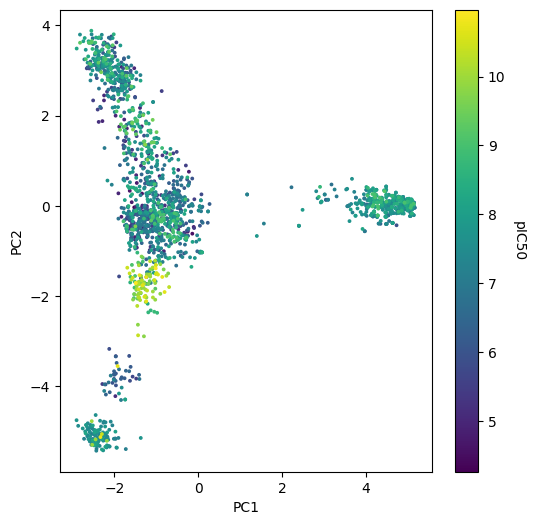

In [13]:
########## Code ##########

# skeleton code for plotting
fig, ax = plt.subplots(figsize=(6,6))

sc = ax.scatter(jak2_pca[:, 0], jak2_pca[:, 1], s=3, c=jak2["pIC50"], cmap="viridis")
cbar = plt.colorbar(sc)
cbar.set_label("pIC50", rotation=270, labelpad=15)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.show()

########## Code ##########

**Task 4**: What is the total percent explained variance of the first 50 principal components? The attributes of [`sklearn.decomposition.PCA()`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) should help with this question.

In [14]:
########## Code ##########
total_variance_50 = pca.explained_variance_ratio_[:50].sum() * 100
print(f"Total explained variance (first 50 PCs): {total_variance_50:.2f}%")

########## Code ###########

Total explained variance (first 50 PCs): 62.53%


**Question:** What patterns do you observe (if any)?

**There are several distinct clusters in the PCA plot instead of one continuous cloud, which suggest. that there are structurally distinct chemical scaffolds in the dataset. pIC50 is not strongly separated by PCA (high and low values are intermixed in the main cluster). 62.53% explained variance across 50 of the original 2048 dimensions means that around 37.5% of the variance is lost when truncating to 50 PCs. This is a meaningful amount, so the 50-PC representation is a lossy compression of the original fingerprint space.**


### 1.3 <font color="blue">(15 points)</font>  Non-linear Dimensionality Reduction: t-SNE analysis on Molecular Fingerprints

PCA applies linear transformations on your data, but may struggle to tease out subtle underlying patterns.  Two popular nonlinear alternatives are **t-SNE** and **UMAP**.

- **t-Distributed Stochastic Neighbor Embedding (t-SNE)** performs a stochastic nonlinear transformation and can be implemented with [sklearn.manifold.TSNE()](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html).  Because it is stochastic, embeddings differ across runs.  The `perplexity` parameter balances attention between local and global structure — small values emphasize local clusters; large values produce a more global, spread-out layout.

- **UMAP** (Uniform Manifold Approximation and Projection) is another nonlinear method that often better preserves global structure and runs faster than t-SNE.  It is available via the [umap-learn](https://umap-learn.readthedocs.io/en/latest/parameters.html) library.

**Task 1**: Apply t‑SNE on the 100‑dimensional PCA embeddings you obtained from the previous part with `n_components=2` with `perplexity=[2,30,500]` separately and produce three labeled t‑SNE plots with points colored by pIC50.  Do you notice any differences in the clustering?  For the `perplexity=30` plot, do you observe any patterns? Note that t-SNE can take a couple minutes to run.

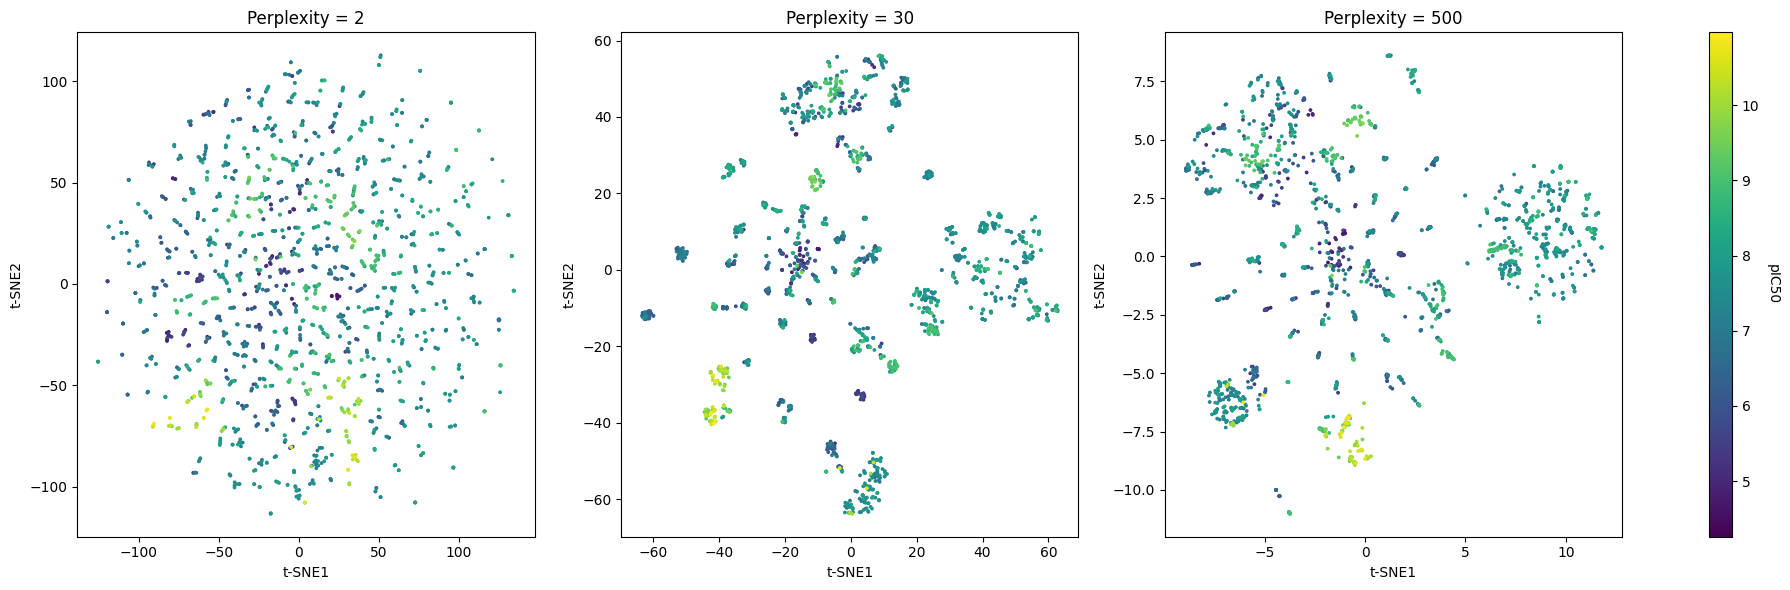

In [15]:
########## Code ##########

fig, ax = plt.subplots(figsize=(18,6), ncols=4, gridspec_kw={"width_ratios": [1,1,1,0.05]})

perplexities = [2, 30, 500]
for i, perplexity in enumerate(perplexities):
    pca_tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42).fit_transform(jak2_pca)


    sc = ax[i].scatter(pca_tsne[:, 0], pca_tsne[:, 1], s=3, c=jak2["pIC50"], cmap="viridis")
    ax[i].set_xlabel("t-SNE1")
    ax[i].set_ylabel("t-SNE2")
    ax[i].set_title(f"Perplexity = {perplexity}")

cbar = plt.colorbar(sc, cax=ax[-1])
cbar.set_label("pIC50", rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

########## Code ##########

**Question:** Do you notice any differences in the clustering between the three t-SNE plots? For the `perplexity=30` plot, do you observe any patterns?

**For perplexity=2, we see overfitting of local structure. There are many tiny, fragmented blobs with very little global meaning. For perplexity=30, there are meaninfgul clusters by pIC50 values. For perplexity=500, it basically treats all points as neighbors which partially collapses local structure back into a more global (PCA-like) view. At perplexity = 30, the most potent molecules (yellow, pIC50 ~10–11) visibly concentrate in one or two specific clusters in the bottom-left, suggesting these high-potency compounds share a common scaffold distinct from the rest of the dataset.**

Let's imagine a biopharmaceutical company is only willing to invest resources into making molecules that have a **pIC50 >= 9.5**, as they consider this threshold important in discerning potent, effective inhibitors of JAK2.

**Task 2:** Discretize the data by classifying any molecule with a pIC50 >= 9.5 as **effective** (i.e., 1) and any with a pIC50 < 9.5 as **ineffective** (i.e., 0). Capture this information as an additional column called `is_effective` in the `jak2` dataframe.

In [16]:
########## Code ##########
jak2["is_effective"] = (jak2["pIC50"] >= 9.5).astype(int)

########## Code ##########

**Task 2:** Apply UMAP, just as you did with t-SNE, on your 100-dimensional PCA embeddings you obtained earlier. Use `n_components=2`, `n_neighbors=10`, and `min_dist=1.0` and produce a plot with effective and ineffective molecules (as defined above) in different colors.

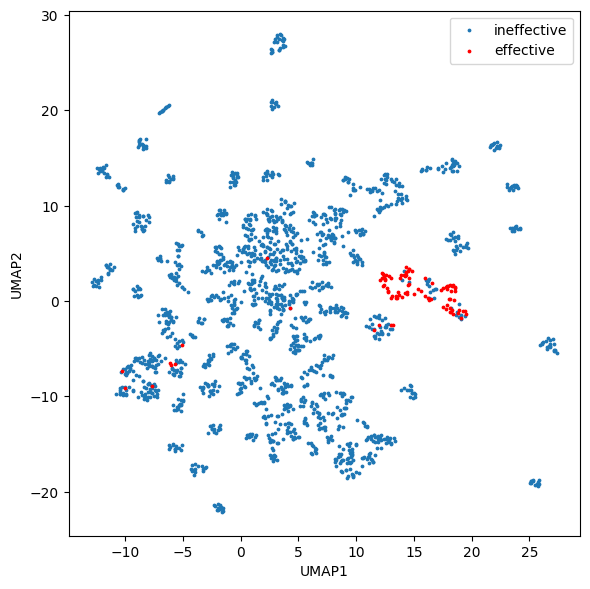

In [17]:
########## Code ##########
pca_umap = UMAP(n_components=2, n_neighbors=10, min_dist=1.0, random_state=42).fit_transform(jak2_pca)

fig, ax = plt.subplots(figsize=(6,6))


mask = jak2["is_effective"] == 0
ax.scatter(pca_umap[mask, 0], pca_umap[mask, 1], s=3, label="ineffective")
ax.scatter(pca_umap[~mask, 0], pca_umap[~mask, 1], color="red", s=3, label="effective")


ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.legend()
plt.tight_layout()
plt.show()
########## Code ##########

**Question:** Compare the PCA, t-SNE (perplexity=30), and UMAP embeddings. Which method best separates effective from ineffective molecules and why? What does this tell you about the structure of the molecular fingerprint space?

**The UMAP most cleanly separates effective molecules. The red points form a coherent cluster in the right center of the plot with only a few scattered points around the plot. While the t-SNE is the best at revealing clustering identity, it does not cleanly isolate effective and ineffective. Additionally, effective and ineffective molecules in the PCA plot overlap heavily because PCA is a linear method that maximizes global variance, not local cluster structure. These observations tell us that the effective molecules occupy a compact and localed region of chemical space (they are structurally similar to each other). Additionally, the fingerprint space is non linear (UMAP and t-SNE are needed to visualize this space).**

### 1.4 <font color="blue">(5 points)</font>: Visualize latent clusters for structure similarity

Note that we don't actually know if these clusters are meaningful; do we know whether the effective compounds (`pIC50 >= 9.5`) that cluster together in the plot really have more in common than the other effective compounds that are far away? Perhaps the t-SNE or UMAP are getting lucky with their projections.

One approach that may help us interpret our latent space is clustering. To make this a bit easier, we will only explore the effective compounds and look at the common features within each cluster. DBSCAN is one effective algorithm for clustering such data.

**Task 1**: Use [sklearn.cluster.DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) to cluster the effective molecules with parameters `eps=0.6` and `min_samples=4` to draw insights on commonalities between groups of these molecules. Visualize, **only** the **effective** clusters, by plotting the UMAP results with unique colors and labels.

First run DBSCAN on only active molecules and visualize with labels.

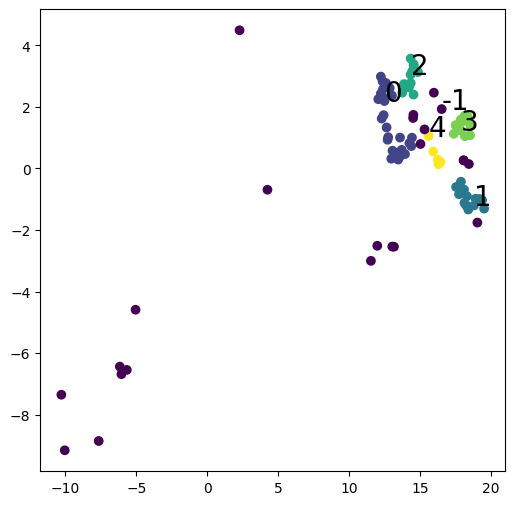

In [18]:
########## Code ##########
# Use DBSCAN to get `labels` for clusters of the actives
effective_mask = jak2["pIC50"] >= 9.5
effective_umap = pca_umap[effective_mask]

labels = DBSCAN(eps=0.6, min_samples=4).fit_predict(effective_umap)

########## Code ##########

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(pca_umap[jak2["pIC50"] >= 9.5][:, 0],
           pca_umap[jak2["pIC50"] >= 9.5][:, 1],
           c=labels)

# add labels as text
for label in np.unique(labels):
    idx = np.argwhere(labels == label)[0]
    x = pca_umap[jak2["pIC50"] >= 9.5][idx, 0][0]
    y = pca_umap[jak2["pIC50"] >= 9.5][idx, 1][0]
    ax.text(x, y, label, size=20)

**Question**: Visualize a couple clusters. Comment on the similarity of structures within clusters. Are they different from those in other clusters?

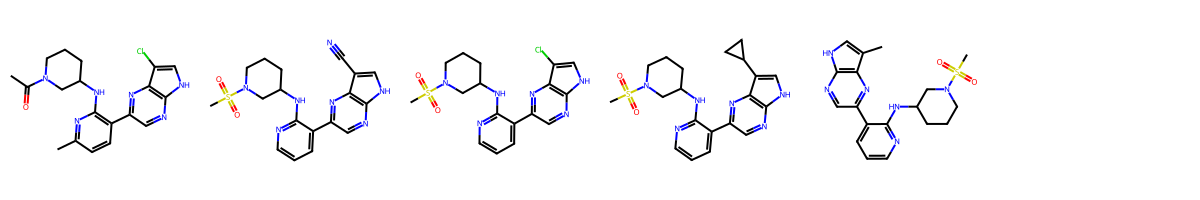

In [19]:
# Run below
label = 4 # CHANGE ME to view different clusters

cluster = jak2.SMILES[jak2["pIC50"] >= 9.5][labels == label]
# visualize all molecules in cluster
mol_list = []
for mol in cluster:
    mol_list.append(Chem.MolFromSmiles(mol))
Draw.MolsToGridImage(mol_list, molsPerRow=6)

**Each cluster does look different, but they all share the same indazole-pyridine hinge-binding core. The main part that differs is pendant functional group on the saturated ring.**

## Part 2: Model Interpretability with SHAP

### (total <font color="blue">50 points</font> <font color="orange"> + 20 points</font>)

In Part 1 you explored molecular representations through the lens of *unsupervised* dimensionality reduction. Here we switch to a *supervised* setting and ask a harder question: **why** does a trained model make its predictions?

Complex models such as Support Vector Machines, Random Forests, and Deep Neural Networks achieve high predictive accuracy, but their internal reasoning is largely opaque. This "black-box" problem is especially critical in drug discovery, where understanding which molecular substructures drive activity can guide medicinal chemistry.

**SHapley Additive exPlanations (SHAP)** offers a rigorous solution. Rooted in cooperative game theory, SHAP assigns each feature a contribution score for a given prediction. Crucially, the sum of all SHAP values plus a global baseline equals the model's actual output — making the decomposition exact and additive. Unlike simple feature importances, SHAP values are *local* (per-feature) and *signed* (positive = pushes toward active, negative = pushes toward inactive).

In this part you will:
1. Load a multi-target activity dataset and set up a binary classification task
2. Train up to three model architectures — SVM, Random Forest, and a neural network
3. Visualize *where* in chemical space the model succeeds and fails, connecting Part 1 to Part 2
4. Apply SHAP to rank the most influential molecular fingerprint bits
5. Map the top bits back onto molecular structures for visual interpretation
6. <font color="orange">(Grad Only)</font> Validate the SHAP rankings by selectively "dropping out" the most important features and measuring performance degradation

### Background

#### The Drug Discovery Problem

A central challenge in drug discovery is identifying small molecules (ligands) that bind to a specific biological target, typically a protein, and modulate its activity. A molecule that binds and inhibits (or activates) a target with measurable affinity is called a **hit**. Finding hits experimentally is expensive and slow: high-throughput screening can test millions of compounds, but only a tiny fraction will be active.

Machine learning offers a shortcut. By training classifiers on known active/inactive compounds, we can predict the activity of new, untested molecules. In this problem set, the target is the **Melatonin receptor 1B** (`CHEMBL1946`), a G-protein-coupled receptor (GPCR) that binds melatonin and is involved in circadian rhythm regulation and glucose homeostasis. It is of interest in medicinal chemistry due to its links to type 2 diabetes and the challenge of designing selective ligands within closely related GPCR subtypes.

We represent molecules as **ECFP fingerprints** (from Part 1) and frame activity prediction as a binary classification problem: **active (1)** vs. **inactive (0)**. Inactives are random "drug-like" molecules drawn from the ZINC database — compounds that look chemically reasonable but likely have no known affinity for our target.

#### Why Interpretability Matters

Even if a model achieves high accuracy, knowing *which molecular features* drive its predictions is crucial:

- **Medicinal chemistry guidance**: If the model has learned that a specific aromatic amine or a particular ring system drives activity, chemists can prioritize synthesizing analogs that preserve or extend that motif.
- **Trust and debugging**: A model might be accurate for the wrong reasons (e.g., it learned a spurious correlation in the training set). Inspecting the features it relies on helps catch this.
- **Scientific insight**: Recurring structural themes across many actives may reveal something about the binding pocket geometry or pharmacophore requirements of the target.

>**Note**: This problem closely follows the methodology of [Rodriguez-Perez & Bajorath (2019), *J. Chem. Inf. Model.*, 59(3), 1021-1030](https://doi.org/10.1021/acs.jmedchem.9b01101) which we slightly alter to be more appropriate for a problem set.

## 2.1 Analyzing our dataset <font color="blue">(5 points)</font>

### Loading the Dataset

[Rodriguez-Perez & Bajorath](https://doi.org/10.1021/acs.jmedchem.9b01101) only included compounds that were active against each protein target with high confidence. For each target, there are at least 200 active compounds belonging to at least 50 different analog series (`AnalogSeriesID`). Molecules within a single **analog series** are typically structurally similar to one another. Ensuring that there is a large amount of different analog series can serve as a proxy for maintaining diversity in the datasets. Diversity is important to reduce the chances that there is only a single e.g., functional group that is responsible for activity. To further reduce any potential structural biases, they also randomly select 1000 compounds from a large drug-like database called ZINC to introduce as "inactives" to include in train/test splits. We will investigate and discuss whether this is a reasonable approach.

**Our data**:
- The ChEMBL dataset (`activity_classes_ChEMBL24.dat`) contains compounds from 10 protein targets selected from ChEMBL 24.
Each row includes a SMILES string, target ID, target name, analog series ID, and pKi value.
- The ZINC dataset (`random_zinc_1000.csv`) contains 1000 compounds randomly selected from the ZINC22 database. Each row includes a SMILES string, ZINC ID, and tranche.

For the purposes of this problem set, we will select target Melatonin receptor-1B (`CHEMBL1946`), but feel free to explore the others on your own. We will treat all compounds belonging to `CHEMBL1946` as *actives* **(label = 1)**, and all compounds from the ZINC dataset as *inactives* **(label = 0)**. We have prepared code for creating a 70/30 train-test series-based split, and featurized it.

**Task**: After running the cells, you will be asked a couple questions about what you observe by visualizing the data and the resulting splits.

In [21]:
# Run: load the dataset and display available activity classes
DATA_PATH = "activity_classes_ChEMBL24.dat.1"

# Visualize a summary of the full dataset
df_all = pd.read_csv(DATA_PATH, sep="\t")
target_counts = df_all.groupby(["TargetID", "TargetName"]).size().reset_index(name="n_compounds")
print("Available activity classes:")
print(target_counts.to_string(index=False))

# Only select the active molecules related to Melatonin receptor-1B
ACTIVE_TARGET_ID = "CHEMBL1946"
df_active = df_all[df_all["TargetID"] == ACTIVE_TARGET_ID].reset_index().copy()

Available activity classes:
  TargetID                               TargetName  n_compounds
CHEMBL1946                    Melatonin receptor 1B          297
 CHEMBL229             Alpha-1a adrenergic receptor          243
 CHEMBL233                       Mu opioid receptor          838
 CHEMBL237                    Kappa opioid receptor          720
 CHEMBL244                     Coagulation factor X          684
 CHEMBL259                  Melanocortin receptor 4          445
 CHEMBL264                    Histamine H3 receptor          961
 CHEMBL344 Melanin-concentrating hormone receptor 1          415
CHEMBL4792                        Orexin receptor 2          400
CHEMBL4860                Apoptosis regulator Bcl-2          294


Let's visualize what compounds are in our actives dataset with a handy tool called [mols2grid](https://mols2grid.readthedocs.io/en/latest/contents.html). The code below will automatically label and sort each molecule with the `AnalogSeriesID`.

In [22]:
mols2grid.display(
    df_active,
    sort_by='AnalogSeriesID',
    subset=['AnalogSeriesID']
)

**Question 1/2 (2.5 points)**: What do you notice about similarity of the structures within a certain analog series (analog series are indicated by their series ID)?

**Compounds within the same AnalogSeriesID share a common core scaffold with variations only at specific substituent positions. For example the compounds labeled 3843 all have the same bicyclic core with a side chain and then differ in substituents in the aromatic ring. The 4010 series also share a similar core with differences in the branching or chain length.**

We need to create a 70/30 train-test, series-based split. Since our classes are imbalanced, there is no clean way to do this with existing functions. Please run the code below which iteratively searches for such a split.

In [23]:
# Run the code below, no changes needed
# create 1000 splits of 70:30
gss = GroupShuffleSplit(n_splits=1000, test_size=0.3, random_state=42)

best_split = None
best_diff = float("inf")

total = len(df_active) # total number of molecules
target = 0.3 * total # target split for test set

# Loop through different splits created by GroupShuffleSplit and find ones that meet our criteria
for train_idx, test_idx in gss.split(df_active['SMILES'], y=None,
                                     groups=df_active['AnalogSeriesID']
                                    ):
    test_size = len(test_idx)
    diff = abs(test_size - target)

    if diff < best_diff:
        best_diff = diff
        best_split = (train_idx, test_idx)

train_idx, test_idx = best_split

print(
    f'Number of training active samples: {len(df_active.iloc[train_idx])}\
    ({len(train_idx)/(len(train_idx) + len(test_idx)):.1%})'
)
print(f'Number of test active samples: {len(df_active.iloc[test_idx])}\
    ({len(test_idx)/(len(train_idx) + len(test_idx)):.1%})'
)

# Ensure that in the train and test sets, there is no overlap of analog series ID.
assert len(set(df_active.iloc[train_idx].AnalogSeriesID.values).intersection(
    set(df_active.iloc[test_idx].AnalogSeriesID.values)
)) == 0

Number of training active samples: 208    (70.0%)
Number of test active samples: 89    (30.0%)


This code block constructs the dataset by adding in the inactive ZINC molecules. This will result in a 70/30 train-test split: `smiles_train`, `y_train`, `smiles_test`, `y_test`. Remember that actives are labeled with a value of `1` and inactives as `0`.

In [25]:
# Run: No changes required

df_active["label"] = 1 # Set active label as 1

smiles_train_active = df_active.iloc[train_idx]['SMILES']
y_train_active = df_active.iloc[train_idx]['label']
smiles_test_active = df_active.iloc[test_idx]['SMILES']
y_test_active = df_active.iloc[test_idx]['label']

# Load the inactives and set label as 0
df_inactive = pd.read_csv('random_zinc_1000.csv.1')
df_inactive['label'] = 0

# split the inactives
smiles_train_inactive, smiles_test_inactive, y_train_inactive, y_test_inactive = train_test_split(
    df_inactive['SMILES'], df_inactive['label'], random_state=0, test_size=0.3)

# Merge the ChEMBL actives and the ZINC inactives
smiles_train = pd.concat((smiles_train_active, smiles_train_inactive)).values
y_train = pd.concat((y_train_active, y_train_inactive)).values
smiles_test = pd.concat((smiles_test_active, smiles_test_inactive)).values
y_test = pd.concat((y_test_active, y_test_inactive)).values

# Shuffle the data
smiles_train, y_train = shuffle(smiles_train, y_train, random_state=0)
smiles_test, y_test = shuffle(smiles_test, y_test, random_state=0)

print(f"Active target: {ACTIVE_TARGET_ID}")
print(f"Total dataset: {len(smiles_train) + len(smiles_test)} compounds ({df_active['label'].sum()} active, {(df_inactive['label']==0).sum()} inactive)")
print(f"Train: {len(smiles_train)}, Test: {len(smiles_test)}")

Active target: CHEMBL1946
Total dataset: 1225 compounds (297 active, 928 inactive)
Train: 857, Test: 368


We followed the papers instructions to split the dataset based on analog series so the train and test sets should have molecules that aren't too related so that we can test generalizability. Let's visualize a few of our active molecules in our train/test splits to see if this actually worked.

In [26]:
# Run: no changes needed
# Train set
# Visualize the first molecule in each analog series (only six series visualized)
unique_train_actives = df_active.iloc[train_idx].sort_values('AnalogSeriesID').drop_duplicates('AnalogSeriesID', keep='first')[:6]
mols2grid.display(
    unique_train_actives,
    subset=['AnalogSeriesID']
)

In [27]:
# Run: no changes needed
# Test set
# Visualize the first molecule in each analog series (only six series visualized)
unique_test_actives = df_active.iloc[test_idx].sort_values('AnalogSeriesID').drop_duplicates('AnalogSeriesID', keep='first')[:6]
mols2grid.display(
    unique_test_actives,
    subset=['AnalogSeriesID']
)

Recall that our data splitting strategy consisted of separating different analog series because we operated under the assumption that molecules within an analog series have similar structures and those in different analog series have different structures. Furthermore, our fingerprinting approach for converting molecules to numerical representations identifies substructures within our molecules.

**Question 2/2 (2.5 points)**: What do you notice about some of these molecules despite being different in series? How might you expect this to impact our predictions? How might we improve the data splitting?

**Even though the molecules were different in series, many of the molecules share similar structural motifs. The bicyclic core appears repeatedly across the train (907, 2061) and test (926) sets. Because the test and train sets share core scaffolds despite being from different series, the series-based split might not be as stringent as we want. A model trained on the test set could still perform well on the test set just by recognizing the shared core scaffold. This would inflate model performance. We could change our splitting method by splitting based on scaffold instead to make sure the core ring systems in each set is different (or we could cluster by chemical similarity).**

**Optional**: Visualize what the inactives from ZINC look like. Are they structurally distinct from the actives?

In [30]:
mols2grid.display(
    df_inactive.sample(24, random_state=42),
    smiles_col="SMILES",
    subset=["label"]
)

**The inactives from ZINC look very different from the actives. Since they are randomly sampled from a large database, they all are very diverse and look pretty unreleated towards the actives.**

Below is a modified ECFP featurizer (`ECFP4_v2`) that is used to featurize your train/test sets. This will produce machine-readable `X_train` and `X_test` inputs. It will also output list of dictionaries `bit_infos_train` and `bit_infos_test` which contain a mapping between each molecule and their corresponding bits. We will need this for a visualization exercise in problem 2.4.

In [31]:
# Run: no changes needed
# This is a modified version of the ECFP class from Part 1.
# The key addition is that we preserve the `bitInfo` dictionary for each molecule,
# which maps each active bit index to the (atom_index, radius) tuples that generated it.
# This is essential for mapping SHAP-important bits back to molecular substructures in Section 2.6.
RADIUS = 3
NUM_BITS = 512

class ECFP4_v2:

    def __init__(self, smiles_list, radius=RADIUS, num_bits=NUM_BITS):
        self.smiles = smiles_list
        self.radius = radius
        self.num_bits = num_bits
        self.mols = [Chem.MolFromSmiles(smi) for smi in self.smiles]
        self.fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=self.radius, fpSize=self.num_bits)
        self.ao = rdFingerprintGenerator.AdditionalOutput()
        self.ao.AllocateBitInfoMap()

    def compute_ECFP(self):
        """Returns (X, bit_infos) where X is (n, num_bits) float array and
        bit_infos is a list of dicts {bit_idx: [(atom_idx, radius), ...]}."""
        fps = []
        bit_infos = []
        for mol in self.mols:
            fp = self.fpgen.GetFingerprintAsNumPy(mol, additionalOutput=self.ao)
            fps.append(fp)
            bit_infos.append(self.ao.GetBitInfoMap())
        return (np.array(fps).astype(np.float32), bit_infos)

# Get ECFP4 fingerprints for the training set
ecfp_train = ECFP4_v2(smiles_train)
X_train, bit_infos_train = ecfp_train.compute_ECFP()

# Get ECFP4 fingerprints for the testing set
ecfp_test = ECFP4_v2(smiles_test)
X_test, bit_infos_test = ecfp_test.compute_ECFP()  # fill me in

print(f'Train fingerprints: {X_train.shape}, Test fingerprints: {X_test.shape}')

Train fingerprints: (857, 512), Test fingerprints: (368, 512)


## 2.2 Train the different models <font color="blue">(15 points)</font> <font color="orange">+ (5 points)</font>
You will train an SVM and RF model. If you are a graduate student, you are also asked to train a DNN.
We will use the **Matthews Correlation Coefficient (MCC)** to quantify the predictive power of your trained models. This metric is well-suited to imbalanced binary classification. You can read more about it [here](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.matthews_corrcoef.html).
- **2.2.1**: SVM (5 pts)
- **2.2.2**: RF (5 pts)
- **2.2.3**: DNN (5 pts, grad only)
- **2.2.4**: Comparison (5 pts)

### 2.2.1 SVM with Tanimoto Kernel <font color="blue">(5 points)</font>

The **Tanimoto coefficient** (also called Jaccard similarity) is the standard similarity metric for binary
molecular fingerprints. For two bit-vectors $\mathbf{a}$ and $\mathbf{b}$:

$$T(\mathbf{a}, \mathbf{b}) = \frac{|\mathbf{a} \cap \mathbf{b}|}{|\mathbf{a} \cup \mathbf{b}|} = \frac{\mathbf{a} \cdot \mathbf{b}}{|\mathbf{a}| + |\mathbf{b}| - \mathbf{a} \cdot \mathbf{b}}$$

Using this as an SVM kernel yields a non-linear classifier that operates natively in chemical similarity space.
We provide the vectorized kernel function below.

In [32]:
# Run: Tanimoto kernel function (vectorized)
def tanimoto_kernel(X, Y):
    """Tanimoto (Jaccard) kernel for binary fingerprint arrays.
    X: (n, d), Y: (m, d) → returns (n, m) kernel matrix."""
    XY = X @ Y.T                                    # dot products (intersections)
    XX = X.sum(axis=1).reshape(-1, 1)               # bit counts for X
    YY = Y.sum(axis=1).reshape(1, -1)               # bit counts for Y
    denom = XX + YY - XY
    denom = np.where(denom == 0, 1e-10, denom)      # avoid division by zero
    return XY / denom

print("Tanimoto kernel function defined.")

Tanimoto kernel function defined.


**Task:** Train an SVM classifier using the Tanimoto kernel provided above.

- Use `sklearn.svm.SVC` with `kernel=tanimoto_kernel`,  `probability=True` with a `random_state` of 42.
- Fit on `X_train`, `y_train`
- Predict on `X_test`
- Compute and report MCC

In [33]:
########## Code ##########
# Train SVM classifier with Tanimoto kernel
svm = SVC(kernel=tanimoto_kernel, probability=True, random_state=42)
svm.fit(X_train, y_train)

# Predict on the test set and report MCC metric
y_pred_svm = svm.predict(X_test)
mcc_svm = matthews_corrcoef(y_test, y_pred_svm)

########## Code ##########
print(f'SVM (Tanimoto kernel) MCC: {mcc_svm:.4f}')

SVM (Tanimoto kernel) MCC: 0.9406


### 2.2.2 Random Forest <font color="blue">(5 points)</font>
**Task:** Train a Random Forest classifier.

- Use `sklearn.ensemble.RandomForestClassifier` with `n_estimators=500` and `random_state=42`
- Fit on `X_train`, `y_train`
- Predict on `X_test`
- Compute and report MCC

In [34]:
########## Code ##########
# Train RF classifier
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

# Predict on the test set and report MCC metric
y_pred_rf = rf.predict(X_test)
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)


########## Code ##########
print(f'Random Forest (500 trees) MCC: {mcc_rf:.4f}')

Random Forest (500 trees) MCC: 0.8808


### 2.2.3 Deep Neural Network <font color="orange">(5 points, Grad only)</font>

We implement a feedforward DNN using PyTorch. The architecture follows the paper:
input (NUM_BITS) → hidden (512, ReLU) → dropout → hidden (256, ReLU) → dropout → output (1, Sigmoid).

**Task:** Complete the `DNN` class and the training loop in the cell below.
- Fill in the `__init__` method to define the layer stack with `nn.Sequential`
- Train for at least 20 epochs using `BCELoss` and `Adam` (lr=1e-3)
- Predict on `X_test` and compute/report MCC
- You are not required to have a validation loop for this exercise

> **IMPORTANT**: Ensure that the output of `forward()` returns a size of (batch_size, 1) to be compatible with SHAP analysis downstream.

In [ ]:
# Complete the __init__ methods

class DNN(nn.Module):
    def __init__(self, input_dim=NUM_BITS, dropout_rate=0.5):
        super().__init__()
        ########## Code ##########



        ########## Code ##########

    def forward(self, x):
        """
        Output size: (batch_size, 1)
        """
        return self.net(x)

print("DNN class defined.")

In [ ]:
# Hyperparameters
EPOCHS = 30
BATCH_SIZE = 64
LR = 1e-3

# Build dataset / dataloader
X_tr_t = torch.tensor(X_train)
y_tr_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1,1)
X_te_t = torch.tensor(X_test)

loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH_SIZE, shuffle=True)

########## Code ##########

dnn_model =  # initialize the model
criterion =  # Set the loss
optimizer =  # set up the optimizer

# Training loop



# Evaluation



########## Code ##########

print(f"\nDNN MCC: {mcc_dnn:.4f}")

### 2.2.4 Comparison of model results <font color="blue">(5 points)</font>

**Question:** Compare the MCC scores of your SVM, RF, and DNN (grad) models. Does any model significantly outperform the others? What do you notice about the overall accuracy level on this dataset, and what might it imply about the difficulty of the task? Write your prediction for how you expect interpretability to vary between each model before we continue.

**The SVM outperformed the RF with a gap of around 0.06 MCC points. This makes sense since the Tanimoto kernel is built for binary molecular fingerprints so the SVM is operating in a similar space. The RF treats each fingerprint bit independently and cannot explicitly use the Jaccard similarity structure between molecules. Both MCC scores are quite high which implies that the task might be easy. The Random Forest model would be the most interpretable because feature importances directly report which fingerprint bits drive predictions. For the SVM, there is no direct per-feature importance score which makes it less interpretable.**

## 2.3 Visualizing Model Performance in Chemical Space <font color="blue">(5 points)</font>

In Part 1 we used dimensionality reduction to visualize chemical space. Now we ask: **where** in that space does our model succeed or fail?

By computing a t-SNE embedding of the *test set* fingerprints and coloring each compound by its prediction outcome (TP/TN/FP/FN), we can see which regions of chemical space the model handles well versus where it makes mistakes.

In [35]:
# Run: compute PCA → t-SNE embedding of test fingerprints
pca_test = PCA(n_components=100)
crds_test = pca_test.fit_transform(X_test)
tsne_test = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(crds_test)
print(f'Test set t-SNE embedding: {tsne_test.shape}')

Test set t-SNE embedding: (368, 2)


**Task:** Use the RF model you trained in Section 2.2 to predict labels for the test set.  Classify each prediction as true positives (TP), true negatives (TN), false postives (FP), or false negatives (FN).  Then produce a scatter plot of the t-SNE test embedding colored by these four categories.

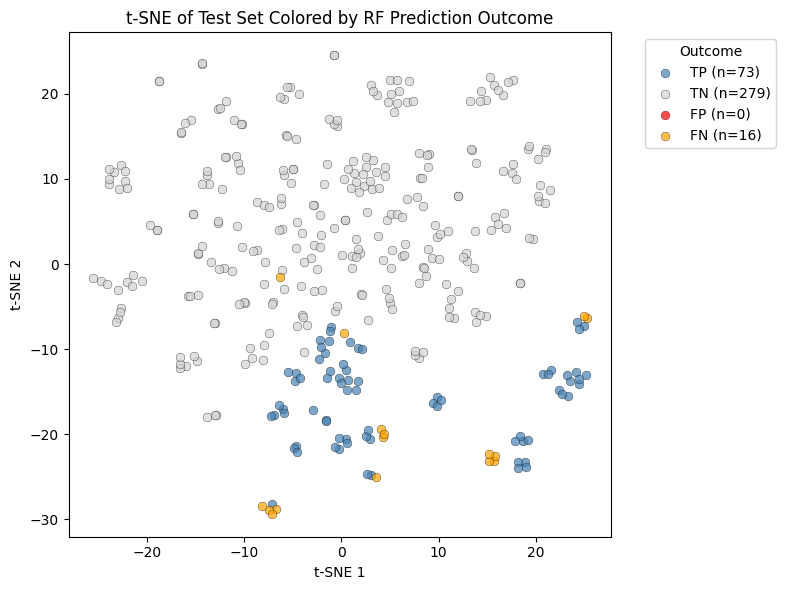

In [36]:
########## Code ##########
y_pred_rf_test = rf.predict(X_test)


# classifying each prediction
labels = []
for true, pred in zip(y_test, y_pred_rf_test):
    if true == 1 and pred == 1:
        labels.append('TP')
    elif true == 0 and pred == 0:
        labels.append('TN')
    elif true == 0 and pred == 1:
        labels.append('FP')
    elif true == 1 and pred == 0:
        labels.append('FN')


# scatterplot of t-SNE embeddings
labels = np.array(labels)

colors = {'TP': 'steelblue', 'TN': 'lightgray', 'FP': 'red', 'FN': 'orange'}

plt.figure(figsize=(8, 6))
for category, color in colors.items():
    mask = labels == category
    plt.scatter(
        tsne_test[mask, 0], tsne_test[mask, 1],
        c=color, label=f'{category} (n={mask.sum()})',
        alpha=0.7, edgecolors='k', linewidths=0.3, s=40
    )

plt.title('t-SNE of Test Set Colored by RF Prediction Outcome')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

########## Code ##########

**Question**:  What patterns do you observe?  Where does the model tend to make errors, and how does this motivate SHAP analysis?

**There is clear separation between actives and inactives in the chemical space. There is a clear cluster for TP in the lower right side of the plot while the TNs occupy the upper regions. The only errors are the FNs which appear in the bottom middle and bottom right area. The t-SNE tells us where errors happen in the chemical space but not why. SHAP analysis will help reveal which specific fingerprint bits drive the model towards active or inactive predictions for each compound so we can look closer at those FNs and potentially see if we have blind spots in the training data.**

## 2.4 SHAP Analysis with `Explainer` modules <font color="blue">(20 points)</font> <font color="orange">+ (5 points)</font>

In Problem 2.3, we see *where* the model fails, but **why**? SHAP analysis can help us peer into the models themselves to try to interpret how they might be making their decisions.

`shap` has multiple specialized modules to approximate Shapley values.
Generally, they approximate Shapley values by:
1. Creating a **background dataset** that represents "typical" feature values (used to simulate missing features)
2. For each test compound, sampling random feature subsets and measuring the change in prediction

**Background via k-means:** Running `KernelExplainer` on the full training set would be extremely slow.
Instead, the paper uses k-means clustering ($k=100$) to condense the training set into representative
centroids. This gives a compact but diverse background that captures the distribution of training fingerprints.
Each SHAP value computation generates `nsamples` random feature coalitions. We use 500
(reduced from the paper's 1000) for speed; this is sufficient for stable ranking of the top features.

**Tasks:**
For each model that you trained
1. Create a k-means background with $k=100$ from `X_train` using `shap.kmeans`
2. Initialize each `Explainer`
   - For SVM, use `shap.KernelExplainer`, the model will need to be `svm_model.predict_proba`, and provide `background.data`.
   - For RF, use `shap.TreeExplainer` and provide `background.data`.
   - For DNN, use `shap.DeepExplainer`, and provide `background.data` as a `Torch.Tensor`.
3. Compute SHAP values for the first 50 test compounds (supply the additional argument `nsamples=500` for `KernelExplainer`)

In [ ]:
# Run: no changes needed
# Step 1: Create k-means background (k=100)
background = shap.kmeans(X_train, 100)
print('Background created:', background.data.shape)

### 2.4.1 Create a `KernelExplainer` for SVM <font color="blue">(5 points)</font>

In [ ]:
N_SHAP = 50

########## Code ##########
# Step 2: Initialize KernelExplainer
svm_explainer =

# Step 3: Compute SHAP values for 50 test samples (this will take several minutes)
print(f"Computing SHAP values for {N_SHAP} test compounds (nsamples=500)...")
svm_shap_values =
# shap_values is a list of 2 arrays (one per class); index [1] = active class
########## Code ##########

svm_shap_vals_active = svm_shap_values[..., 1]  # shape: (N_SHAP, NUM_BITS)
print("SHAP computation complete. Shape:", svm_shap_vals_active.shape)

### 2.4.2 Create a `TreeExplainer` for RF <font color="blue">(5 points)</font>

In [ ]:
########## Code ##########

# Initialize TreeExplainer on RF
rf_explainer =

# Step 3: Compute SHAP values for 50 test samples (this will take several minutes)
print(f"Computing SHAP values for {N_SHAP} test compounds (nsamples=500)...")
rf_shap_values =
# shap_values is a list of 2 arrays (one per class); index [1] = active class

########## Code ##########

rf_shap_vals_active = rf_shap_values[..., 1]  # shape: (N_SHAP, NUM_BITS)
print("SHAP computation complete. Shape:", rf_shap_vals_active.shape)

### 2.4.3 Create a `DeepExplainer` for the DNN <font color="orange">(5 points, Grad only)</font>

In [ ]:
########## Code ##########
# Step 2: Initialize DeepExplainer
dnn_explainer =

# Step 3: Compute SHAP values for 50 test samples (this will take several minutes)
print(f"Computing SHAP values for {N_SHAP} test compounds")
dnn_shap_values =
# shap_values is a list of 2 arrays (one per class); index [1] = active class

########## Code ##########
dnn_shap_vals_active = dnn_shap_values[..., 0]  # shape: (N_SHAP, NUM_BITS)
print("SHAP computation complete. Shape:", dnn_shap_vals_active.shape)

### 2.4.4 Distribution and Analysis of SHAP Importance <font color="blue">(10 points)</font>

**Task**: Make a bar chart that shows the top 20 ECFP4 bits of global SHAP importance (mean |SHAP| across test compounds) and/or the full sorted distribution for at least the RF model.

Then answer the following questions:
1. How many bits appear to dominate the SHAP importance (i.e., how sparse is the distribution)?
2. What does this sparsity tell you about the ECFP4 fingerprint for this target?
3. Do the top bits have positive or negative SHAP values for active compounds? What does this mean?

In [ ]:
########## Code ##########

# Global importance = mean |SHAP| per feature across test compounds
# you will need this variable later
rf_mean_abs_shap = # shape: (NUM_BITS,)

# Bar chart of top 20 features or full sorted distribution



########## Code ##########

(Optional) You can also play around with `shap`'s built-in viewer, too.

In [ ]:
# shap.initjs()
# shap.plots.force(
#     rf_explainer.expected_value[0], # model_explainer.expected_value[0]
#     rf_shap_values[..., 0], # model_shap_values[..., 0] or model_shap_values[test_idx, bit_idx, model_pred]
# )

**Write answer here:**

## 2.5 Substructure Visualization <font color="blue">(5 points)</font>

Since the labeling of "bits" is uninterpretable to humans, it can be useful to visualize the relative importance of each bit on the molecule structure. For this exercise, we will map the most important SHAP bits back to the molecular substructures that generated them.

Each entry in the `bitInfo` dictionary has the form:
```
bit_index → [(center_atom_idx, radius), ...]
```
A Morgan fingerprint bit at radius $r$ centered on atom $a$ encodes the circular environment of $a$
out to $r$ bonds. We recover all atoms in that environment using `Chem.FindAtomEnvironmentOfRadiusN`
and highlight them.

We color atoms by the **sign** of their SHAP contribution:
- **Green** = positive SHAP (pushes prediction toward active)
- **Red** = negative SHAP (pushes prediction toward inactive)

We provide the relevant helper functions `visualize_shap_molecule` to visualize the results.

In [ ]:
# Run: substructure visualization helper
def get_highlighted_atoms_bonds_per_bit(mol, bit_info, shap_row, top_n=5):
    """Build multi-color highlight maps for each bit.

    Overlapping environments accumulate multiple colors per atom/bond without blending.

    Not used explicitly in the pset, but feel free to try it out!
    """
    with plt.style.context('tableau-colorblind10'):
        palette = [mcolors.to_rgb(f'C{i}') for i in range(10)]
    top_bits = np.argsort(np.abs(shap_row))[-top_n:][::-1]
    if len(top_bits.shape) > 1:
        top_bits = top_bits.reshape(-1)
    atom_highlights = defaultdict(list)
    bond_highlights = defaultdict(list)
    atom_rads = {}
    rad = 0.35
    for i, bit in enumerate(top_bits):
        if bit not in bit_info:
            continue
        color = palette[i % len(palette)]
        for center_atom, radius in bit_info[bit]:
            if radius == 0:
                atoms_in_env = {center_atom}
                bonds_in_env = set()
            else:
                env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, center_atom)
                atoms_in_env = set()
                bonds_in_env = set()
                for bond_idx in env:
                    bond = mol.GetBondWithIdx(bond_idx)
                    a1, a2 = (bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())
                    atoms_in_env.update([a1, a2])
                    bonds_in_env.add(bond_idx)
                atoms_in_env.add(center_atom)
            for a in atoms_in_env:
                atom_highlights[a].append(color)
                atom_rads[a] = rad
            for b in bonds_in_env:
                bond_highlights[b].append(color)
    return (atom_highlights, bond_highlights, atom_rads)

def get_highlighted_atoms_bonds_contribution(mol, bit_info, shap_row, top_n=5):
    """Build highlight maps for DrawMoleculeWithHighlights colored by SHAP sign.

    Same top-|SHAP| bit ranking as ``get_highlighted_atoms_bonds``, but each bit's
    environment is drawn in green (positive SHAP: active) or red (negative
    SHAP: inactive). Overlapping environments still
    accumulate multiple colors per atom/bond.
    """
    green = mcolors.to_rgb('#2ca02c')
    red = mcolors.to_rgb('#d62728')
    top_bits = np.argsort(np.abs(shap_row))[-top_n:][::-1]
    if len(top_bits.shape) > 1:
        top_bits = top_bits.reshape(-1)
    shap_flat = np.asarray(shap_row).reshape(-1)
    atom_highlights = defaultdict(list)
    bond_highlights = defaultdict(list)
    atom_rads = {}
    rad = 0.35
    for bit in top_bits:
        if bit not in bit_info:
            continue
        val = float(shap_flat[int(bit)])
        if val > 0:
            color = green
        elif val < 0:
            color = red
        for center_atom, radius in bit_info[bit]:
            if radius == 0:
                atoms_in_env = {center_atom}
                bonds_in_env = set()
            else:
                env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, center_atom)
                atoms_in_env = set()
                bonds_in_env = set()
                for bond_idx in env:
                    bond = mol.GetBondWithIdx(bond_idx)
                    a1, a2 = (bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())
                    atoms_in_env.update([a1, a2])
                    bonds_in_env.add(bond_idx)
                atoms_in_env.add(center_atom)
            for a in atoms_in_env:
                atom_highlights[a].append(color)
                atom_rads[a] = rad
            for b in bonds_in_env:
                bond_highlights[b].append(color)
    return (atom_highlights, bond_highlights, atom_rads)

def visualize_shap_molecule(smiles, bit_info, shap_row, top_n=5, size=(400, 300)):
    """Draw a molecule with SHAP-important bits highlighted.

    Arguments
        mol: rdkit mol
        bit_info: (dict) the relevant bit_info from ECFP4_v2 corresponding to the mol
        shap_row: shap_values[mol_idx, :, 1]
        top_n: Number of top bits to visualize if they contribute

    Return
        an SVG.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    atom_h, bond_h, atom_rads = get_highlighted_atoms_bonds_contribution(mol, bit_info, shap_row, top_n=top_n)
    prep = rdMolDraw2D.PrepareMolForDrawing(mol)
    if prep is not None:
        mol = prep
    drawer = rdMolDraw2D.MolDraw2DSVG(size[0], size[1])
    dopts = drawer.drawOptions()
    dopts.addAtomIndices = False
    dopts.useBWAtomPalette()
    dopts.atomHighlightsAreCircles = True
    drawer.DrawMoleculeWithHighlights(mol, '', dict(atom_h), dict(bond_h), atom_rads, {})
    drawer.FinishDrawing()
    return drawer.GetDrawingText()

def svg2html(list_svgs):
    """ Renders svg images in html in a 4x1 format """
    assert len(list_svgs) == 4
    html = '\n<div style="\n    display: flex;\n    flex-direction: row;\n    flex-wrap: nowrap;\n    gap: 20px;\n    overflow-x: auto;\n">\n'
    for svg in list_svgs:
        html = html + f'<div>{svg}</div>'
    html = html + '</div>'
    return HTML(html)  # SVG

**Task:** Visualize the top SHAP substructures for any four *active* test compounds.

1. Find 4 test compounds with label = 1 (active) from your test set
2. For each, call `visualize_shap_molecule` with `top_n=5`
3. Display the 4 highlighted molecule images with `svg2html` for each model you trained.
   - not that `svg2html` expects *only* 4 svgs

In [ ]:
# Find 4 active compounds in the test set (within the first 50 SHAP compounds)
active_test_idx = np.where(y_test[:50] == 1)[0][:4]

########## Code ##########

# store the SVGs for each model
rf_svg_images_active = []
svm_svg_images_active = []
dnn_svg_images_active = []

for _idx in active_test_idx:


########## Code ##########

In [ ]:
display(svg2html(rf_svg_images_active))

In [ ]:
display(svg2html(svm_svg_images_active))

In [ ]:
# (Grad)
display(svg2html(dnn_svg_images_active))

**Question:**

1. Describe the highlighted substructures you observe. Are they consistent across each model?
2. If you do see differences between models, what might this indicate? How does this relate to the accuracy of the model?

> Note: some of the substructures won't show any highlighting and that is okay.

**Write answer here**

## 2.6 Feature Dropout Experiment <font color="orange">(10 points, Grad only)</font>

The SHAP values tell us which fingerprint bits are most important for the model's predictions. But are these rankings *valid* — do they truly capture the chemical drivers of activity, or are they spurious artifacts of the model?

We can empirically validate SHAP by **ablating features** and measuring the performance drop:

- **SHAP-guided dropout:** Remove the top-$N$ bits ranked by mean $|\text{SHAP}|$ (the most important features first)
- **Random dropout:** Remove $N$ randomly selected bits (a control)

If SHAP rankings are meaningful, targeted removal of SHAP-important bits should **degrade performance much faster** than random removal. Random removal should barely affect performance — because ECFP4 fingerprints are highly redundant (512 bits encode far more information than is needed to distinguish active from inactive).

**Task:**
1. Use `rf_mean_abs_shap` from Section 2.4 to rank all 512 bits
2. For each count in `[4, 10, 80, 160, 320, 400, 450, 500]`, perform:
   - **SHAP dropout:** Zero out the top-N SHAP bits in both `X_train` and `X_test`, retrain only the **RF** model and compute MCC
   - **Random dropout:** Zero out N randomly chosen bits, retrain the RF, compute MCC (average over 3 random seeds)
3. Plot MCC vs. number of removed features for both dropout strategies on the same axes

In [ ]:

DROPOUT_COUNTS = [4, 10, 80, 160, 320, 400, 450, 500]
N_RANDOM_SEEDS = 3

########## Code ##########
# Rank bits by SHAP importance (descending)
shap_ranked_bits =

mcc_shap_dropout = []
mcc_random_dropout = []

for n_drop in DROPOUT_COUNTS:
    # SHAP-guided dropout




    mcc_shap_dropout.append()

    # Random dropout (average over 3 seeds)
    rand_mccs = []
    for seed in range(N_RANDOM_SEEDS):
        rng = np.random.default_rng(seed)
        rand_bits = rng.choice(NUM_BITS, size=n_drop, replace=False)


        # fill in below





    mcc_random_dropout.append()

    print(f"Removed {n_drop:3d} bits — SHAP MCC: {mcc_shap_dropout[-1]:.4f}, Random MCC: {mcc_random_dropout[-1]:.4f}")

# Baseline (no dropout)
mcc_baseline =

########## Code ##########

# Plot
fig_drop, ax_drop = plt.subplots(figsize=(7, 4))
ax_drop.axhline(mcc_baseline, color="gray", linestyle="--", label=f"Baseline (no dropout, MCC={mcc_baseline:.3f})")
ax_drop.plot(DROPOUT_COUNTS, mcc_shap_dropout, "o-", color="crimson", label="SHAP-guided dropout")
ax_drop.plot(DROPOUT_COUNTS, mcc_random_dropout, "s--", color="steelblue", label="Random dropout (avg 3 seeds)")
ax_drop.set_xlabel("Number of bits removed")
ax_drop.set_ylabel("MCC on test set")
ax_drop.set_title("Feature Dropout Experiment: SHAP vs. Random (RF)")
ax_drop.legend()
ax_drop.set_xscale("log")
ax_drop.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Question:**

1. Describe the divergence between the SHAP-guided and random dropout curves.
2. Why does removing randomly chosen bits barely affect model performance?
3. What does the rapid MCC degradation from SHAP-targeted removal tell you about those features?
4. What does this experiment validate about the SHAP methodology?

**Write answer here**

---

# Submission

Congratulations! You've reached the end of the pset. Please submit your completed work as a `.ipynb` to Gradescope. Furthermore, if you had any AI-based assistance or worked with collaborators, please list them in the following cell.

**For submission:**
If your file is less than 10mb, feel free to turn in the `.ipynb` directly.

However, if it is >10mb, please take a look at the `# --- Configuration ---` section of the next cell. You will need to change the `NOTEBOOK_NAME` to match the name of your google colab notebook. After making the applicable changes, make sure to save your file, and then please run the cell which will reduce the size of your generated images and aim for a file size of less than 10 mb. Note that it will also delete cells tagged as "background". Check the output to ensure it didn't delete any of your outputs.

When successful, you'll be prompted to download the reformatted notebook which you can then upload to gradescope.

In [ ]:
import io
import os
import base64
import nbformat
import sys
import time
from PIL import Image
from IPython.display import display, Javascript, HTML

# --- Configuration ---
NOTEBOOK_NAME = "ASSIGNMENT_NAME.ipynb" # The name of your file
OUTPUT_FILENAME = "pset_4_bio_submission.ipynb"
TAG_TO_REMOVE = "background"
MAX_IMG_WIDTH = 800
# Standard locations where Colab saves notebooks.
# IF YOU CHANGE THE LOCATION OF YOUR NOTEBOOK PLEASE ADD THE PATH HERE.
COLAB_PATHS = [
    f"/content/drive/MyDrive/Colab Notebooks/{NOTEBOOK_NAME}",
    f"/content/drive/MyDrive/{NOTEBOOK_NAME}"
]
# ---------------------

def get_input_path():
    """Determines the path of the notebook based on the environment."""
    if 'google.colab' in sys.modules:
        from google.colab import drive
        # 1. Mount Drive
        if not os.path.exists('/content/drive'):
            print("Mounting Google Drive to access the notebook file...")
            drive.mount('/content/drive')

        for path in COLAB_PATHS:
            if os.path.exists(path):
                return path

        # Fallback if not found
        print(f"\nERROR: Could not find '{NOTEBOOK_NAME}' in your Google Drive.")
        print("Please ensure the file is saved in 'My Drive' or 'Colab Notebooks'.")
        return None

    else:
        # Local Jupyter (runs in current directory)
        return NOTEBOOK_NAME

def resize_base64_image(b64_str, mime_type):
    # (Same resize logic as before - keeping it brief for readability)
    try:
        img_data = base64.b64decode(b64_str)
        img = Image.open(io.BytesIO(img_data))
        if img.width > MAX_IMG_WIDTH:
            ratio = MAX_IMG_WIDTH / img.width
            new_height = int(img.height * ratio)
            img = img.resize((MAX_IMG_WIDTH, new_height), Image.Resampling.LANCZOS)
            buf = io.BytesIO()
            fmt = 'PNG' if 'png' in mime_type else 'JPEG'
            img.save(buf, format=fmt, optimize=True)
            return base64.b64encode(buf.getvalue()).decode('utf-8')
        return b64_str
    except Exception as e:
        return b64_str

def generate_submission():
    # Trigger a save in the browser
    display(Javascript('IPython.notebook.save_checkpoint();'))
    time.sleep(5)

    input_path = get_input_path()
    if not input_path:
        return

    print(f"Reading notebook from: {input_path}")

    try:
        with open(input_path, 'r', encoding='utf-8') as f:
            nb = nbformat.read(f, as_version=4)
    except Exception as e:
        print(f"Error reading file: {e}")
        return

    new_cells = []

    # Filter Cells & Process Images
    for cell in nb.cells:
        tags = cell.get('metadata', {}).get('tags', [])
        tags = [t.lower() for t in tags] if tags else []
        if TAG_TO_REMOVE in tags:
            continue

        if 'outputs' in cell:
            for output in cell['outputs']:
                data = output.get('data', {})
                for mime_type in ['image/png', 'image/jpeg']:
                    if mime_type in data:
                        data[mime_type] = resize_base64_image(data[mime_type], mime_type)
        new_cells.append(cell)

    nb.cells = new_cells

    with open(OUTPUT_FILENAME, 'w', encoding='utf-8') as f:
        nbformat.write(nb, f)

    # Download logic for Colab
    if 'google.colab' in sys.modules:
        from google.colab import files
        print(f"Downloading {OUTPUT_FILENAME}...")
        files.download(OUTPUT_FILENAME)
        print(f"Success! {OUTPUT_FILENAME} downloaded.")
    else:
        print(f"Success! {OUTPUT_FILENAME} created.")
        display(HTML(f'<br/><a href="{OUTPUT_FILENAME}" download><b>Click here to download {OUTPUT_FILENAME}</b></a>'))

generate_submission()